## 模型使用工具是由一个工具选项的
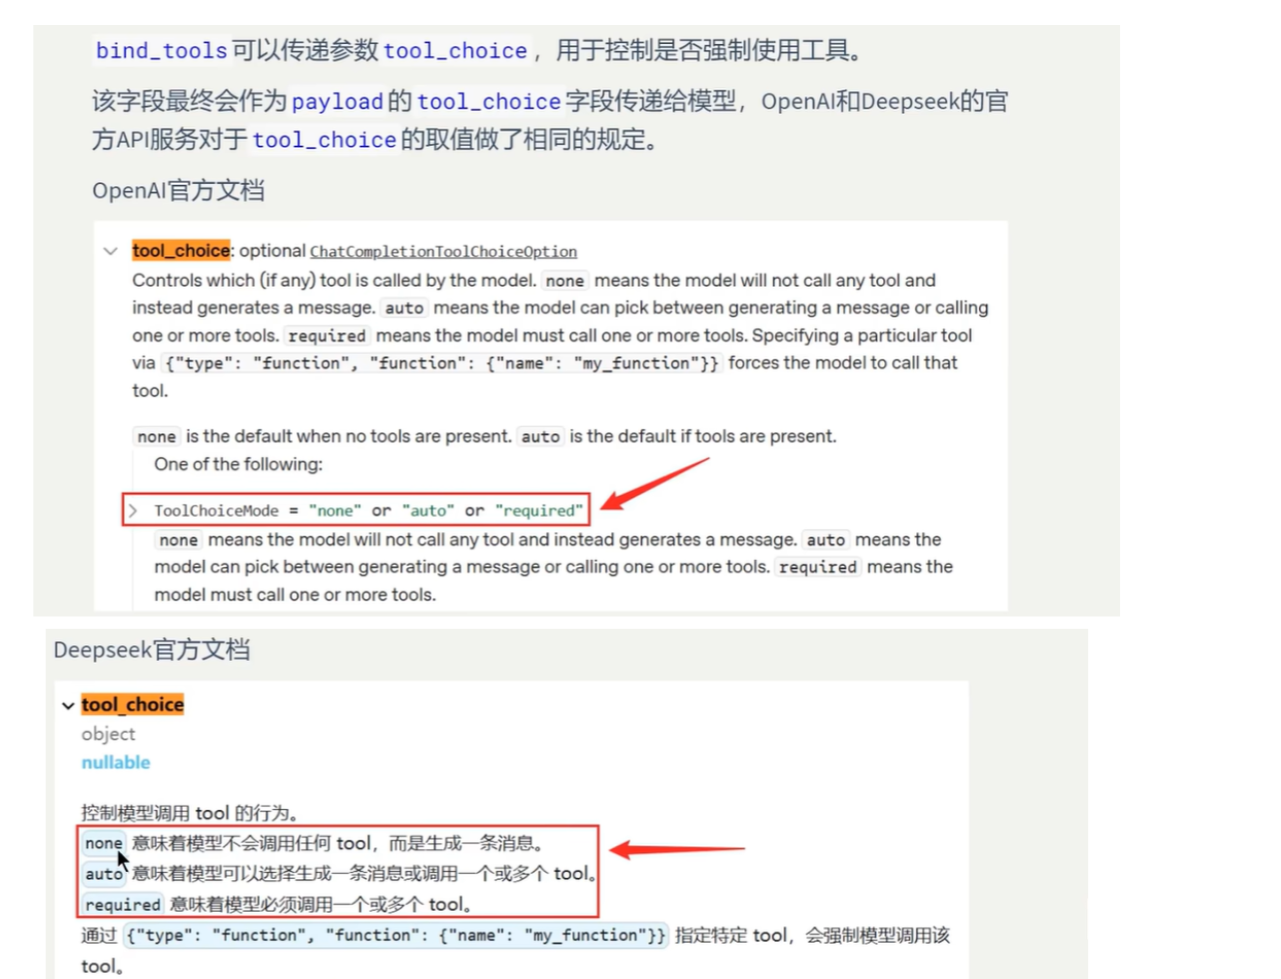

## 举例1 none枚举值的使用

## tool_choice="none"

In [ ]:
from model_utils import create_qwen3_instance
from tool_utils import get_weather2 # 工具也可以从外表导入
from langchain_core.messages import HumanMessage
from rich import print as rprint

model = create_qwen3_instance() # 创建模型的函数也可以从外部导入

## 1.将工具绑定到模型上
tmodel = model.bind_tools([get_weather2],tool_choice='none')
## 2.创建应该消息列表
msgs = [HumanMessage("杭州明天的天气任何？明天呢")]
## 3.调用模型
resp = tmodel.invoke(msgs)
## 4.把返回的消息添加到信息列表
msgs.append(resp)
## 5.获取tool_calls列表
tool_calls = resp.tool_calls
for tool_call in tool_calls:
    if tool_call['name'] == 'get_weather2':
        # 5.1调用工具
        tmsg = get_weather2.invoke(tool_call)
        msgs.append(tmsg)
## 6.把我们获取到的数据提供给模型
resp_final = tmodel.invoke(msgs)
rprint(resp_final)

AIMessage(
    content='杭州明天的天气预报显示有大到暴雨，建议您出门时携带雨具并注意出行安全。当前系统返回的天气信息可能存在重
复或冲突，但根据具体预报内容，明天将有较强降雨，请做好防雨准备。',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 412,
            'prompt_tokens': 237,
            'total_tokens': 649,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 183}
        },
        'model_provider': 'openai',
        'model_name': 'qwen3-vl:latest',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-890',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--01a0cae2-eae3-75f0-978d-13b2e710509f-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 237,
        'output_tokens': 412,
        'total_tokens': 649,
        'input_token_details': {'cache_read': 183},
        'output_token_details': {}
    }
)

## 举例2.auto
## tool_choice="auto",这是默认值，模型会根据你的提示词来确定是否调用工具，有需要就会调用，没有需要就不会调用

In [ ]:
from model_utils import create_qwen3_instance
from tool_utils import query_weather_from_web # 工具也可以从外表导入
from langchain_core.messages import HumanMessage
from rich import print as rprint

model = create_qwen3_instance() # 创建模型的函数也可以从外部导入

## 1.将工具绑定到模型上
# tmodel = model.bind_tools([get_weather2])
tmodel = model.bind_tools([query_weather_from_web],tool_choice="auto")
## 2.创建应该消息列表
msgs = [HumanMessage("郑州明天的天气任何？明天呢")] # 这是需要调用工具的场景
## 3.调用模型
resp = tmodel.invoke(msgs)
## 4.把返回的消息添加到信息列表
msgs.append(resp)
## 5.获取tool_calls列表
tool_calls = resp.tool_calls
for tool_call in tool_calls:
    if tool_call['name'] == 'query_weather_from_web':
        # 5.1调用工具
        tmsg = query_weather_from_web.invoke(tool_call)
        msgs.append(tmsg)
## 6.把我们获取到的数据提供给模型
resp_final = tmodel.invoke(msgs)
## 7.添加到信息列表
msgs.append(resp_final)
## 8.遍历输出所有信息
for msg in msgs:
    msg.pretty_print()
rprint(resp_final)

================================ Human Message =================================

郑州明天的天气任何？明天呢
================================== Ai Message ==================================
Tool Calls:
  query_weather_from_web (call_is68hmih)
 Call ID: call_is68hmih
  Args:
    city: 郑州
================================= Tool Message =================================
Name: query_weather_from_web

{"location": {"name": "郑州", "region": "Henan", "country": "中国", "lat": 34.6836, "lon": 113.5325, "tz_id": "Asia/Shanghai", "localtime_epoch": 1790112331, "localtime": "2026-09-23 05:25"}, "current": {"last_updated_epoch": 1790111700, "last_updated": "2026-09-23 05:15", "temp_c": 22.8, "temp_f": 73.0, "is_day": 0, "condition": {"text": "Smoky haze", "icon": "//cdn.weatherapi.com/weather/64x64/night/149.png", "code": 1036}, "wind_mph": 2.7, "wind_kph": 4.3, "wind_degree": 201, "wind_dir": "SSW", "pressure_mb": 1015.0, "pressure_in": 29.98, "precip_mm": 0.0, "precip_in": 0.0, "humidity": 69, "cloud": 100, "fee

In [3]:
from model_utils import create_qwen3_instance
from tool_utils import query_weather_from_web # 工具也可以从外表导入
from langchain_core.messages import HumanMessage
from rich import print as rprint

model = create_qwen3_instance() # 创建模型的函数也可以从外部导入

## 1.将工具绑定到模型上
# tmodel = model.bind_tools([get_weather2])
tmodel = model.bind_tools([query_weather_from_web],tool_choice="auto")
## 2.创建应该消息列表
msgs = [HumanMessage("河南的省会在哪里？")] # 不需要使用查询天气的工具的场景
## 3.调用模型
resp = tmodel.invoke(msgs)
## 4.把返回的消息添加到信息列表
msgs.append(resp)
## 5.获取tool_calls列表
tool_calls = resp.tool_calls
for tool_call in tool_calls:
    if tool_call['name'] == 'query_weather_from_web':
        # 5.1调用工具
        tmsg = query_weather_from_web.invoke(tool_call)
        msgs.append(tmsg)
## 6.把我们获取到的数据提供给模型
resp_final = tmodel.invoke(msgs)
## 7.添加到信息列表
msgs.append(resp_final)
## 8.遍历输出所有信息
# for msg in msgs:
#     msg.pretty_print()
rprint(resp_final)

AIMessage(
    content='需要直接回答问题，无需调用工具。\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": 
{"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city": "郑州", "aqi": 
"", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "arguments": {"city":
"郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", 
"arguments": {"city": "郑州", "aqi": "", "language": ""}}\n</function-call>\n\n<function-call>\n{"name": 
"query_weather_from_web", "arguments": {"city": "郑州", "aqi": "", "language": 
""}}\n</function-call>\n\n<function-call>\n{"name": "query_weather_from_web", "ar

## 举例3. tool_choice='required',强制模型使用工具，不管有没有必要

In [ ]:
from model_utils import create_qwen3_instance,create_gemma4_instance
from tool_utils import query_weather_from_web # 工具也可以从外表导入
from langchain_core.messages import HumanMessage
from rich import print as rprint

# model = create_qwen3_instance() # 创建模型的函数也可以从外部导入,这个模型不能识别"required"标识
model = create_gemma4_instance() # gemma4不能识别"required"标识
## 1.将工具绑定到模型上
# tmodel = model.bind_tools([get_weather2])
tmodel = model.bind_tools([query_weather_from_web],tool_choice="required")
## 2.创建应该消息列表
msgs = [HumanMessage("河南的省会在哪里？")] # 不需要使用查询天气的工具的场景
## 3.调用模型
resp = tmodel.invoke(msgs)
## 4.把返回的消息添加到信息列表
msgs.append(resp)
## 5.获取tool_calls列表
tool_calls = resp.tool_calls
for tool_call in tool_calls:
    if tool_call['name'] == 'query_weather_from_web':
        # 5.1调用工具
        tmsg = query_weather_from_web.invoke(tool_call)
        msgs.append(tmsg)
## 6.把我们获取到的数据提供给模型
resp_final = tmodel.invoke(msgs)
## 7.添加到信息列表
msgs.append(resp_final)
## 8.遍历输出所有信息
# for msg in msgs:
#     msg.pretty_print()
rprint(resp_final)

AIMessage(
    content='河南的省会是**郑州市**。',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 223,
            'prompt_tokens': 111,
            'total_tokens': 334,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 91}
        },
        'model_provider': 'openai',
        'model_name': 'gemma4:latest',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-293',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--01a0cb5c-a4a1-7ab3-aee5-d8f54325f0bc-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 111,
        'output_tokens': 223,
        'total_tokens': 334,
        'input_token_details': {'cache_read': 91},
        'output_token_details': {}
    }
)

## 举例4，要求模型使用指定的工具

In [2]:
from model_utils import create_qwen3_instance,create_gemma4_instance
from tool_utils import query_weather_from_web,get_weather2 # 工具也可以从外表导入
from langchain_core.messages import HumanMessage
from rich import print as rprint

# model = create_qwen3_instance() # 创建模型的函数也可以从外部导入
model = create_gemma4_instance() # 创建模型的函数也可以从外部导入

## 1.将工具绑定到模型上
# tmodel = model.bind_tools([get_weather2])
tmodel = model.bind_tools([get_weather2,query_weather_from_web],tool_choice="query_weather_from_web")
## 2.创建应该消息列表
msgs = [HumanMessage("郑州明天的天气任何？明天呢")] # 这是需要调用工具的场景
## 3.调用模型
resp = tmodel.invoke(msgs)
## 4.把返回的消息添加到信息列表
msgs.append(resp)
## 5.获取tool_calls列表
tool_calls = resp.tool_calls
for tool_call in tool_calls:
    if tool_call['name'] == "get_weather2":
       tmsg = get_weather2.invoke(tool_call)
       msgs.append(tmsg) 
    elif tool_call['name'] == 'query_weather_from_web':
        # 5.1调用工具
        tmsg = query_weather_from_web.invoke(tool_call)
        msgs.append(tmsg)  
## 6.把我们获取到的数据提供给模型
resp_final = tmodel.invoke(msgs)
## 7.添加到信息列表
msgs.append(resp_final)
## 8.遍历输出所有信息
# for msg in msgs:
#     msg.pretty_print()
rprint(resp_final)

AIMessage(
    content='郑州明天天气不错，但也要注意，明天有大到暴雨。',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 170,
            'prompt_tokens': 226,
            'total_tokens': 396,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 168}
        },
        'model_provider': 'openai',
        'model_name': 'gemma4:latest',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-249',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--01a0cb66-2e79-77b3-a83a-345f3cf14c64-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 226,
        'output_tokens': 170,
        'total_tokens': 396,
        'input_token_details': {'cache_read': 168},
        'output_token_details': {}
    }
)

In [3]:
for msg in msgs:
    msg.pretty_print()

================================ Human Message =================================

郑州明天的天气任何？明天呢
================================== Ai Message ==================================
Tool Calls:
  get_weather2 (call_fcw7hm5t)
 Call ID: call_fcw7hm5t
  Args:
    city: 郑州
    if_forecast: True
================================= Tool Message =================================
Name: get_weather2

郑州明天天气不错
郑州明天有大到暴雨
================================== Ai Message ==================================

郑州明天天气不错，但也要注意，明天有大到暴雨。
